In [1]:
#Nesta etapa são importadas e carregadas as bibliotecas necessárias para manipulação e análise dos dados.

import pandas as pd
import numpy as np

df_itens = pd.read_csv('itens.csv')
df_produtos = pd.read_csv('produtos.csv')
df_traducao = pd.read_csv('traducao.csv')
df_avaliacoes = pd.read_csv('avaliacoes.csv')

In [2]:
# Foi realizada uma inspeção das tabelas para verificar estrutura, tipos de dados e possíveis valores ausentes.

print('\nANÁLISE DETALHADA DAS TABELAS ')
print(f'Produtos: {df_produtos.shape[0]} linhas')
print(f'Itens (Vendas): {df_itens.shape[0]} linhas')
print(f'Traduções: {df_traducao.shape[0]} categorias')
print(f'Avaliações: {df_avaliacoes.shape[0]} linhas')

# Exibindo os dados das tabelas principais para verificar os tipos (Dtype)
print('\nEstrutura de Produtos:')
df_produtos.info()
print('\nEstrutra de Itens:')
df_itens.info()
print('\nEstrutura de Avaliações:')
df_avaliacoes.info()

# Verificando valores ausentes nas tabelas
print("\nValores nulos em Produtos:")
print(df_produtos.isnull().sum())
print("\nValores nulos em Itens:")
print(df_itens.isnull().sum())
print("\nValores nulos em Avaliações:")
print(df_avaliacoes.isnull().sum())


ANÁLISE DETALHADA DAS TABELAS 
Produtos: 32951 linhas
Itens (Vendas): 112650 linhas
Traduções: 71 categorias
Avaliações: 99224 linhas

Estrutura de Produtos:
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB

Estrutra de Itens:
<class 'pandas.DataFrame'>
RangeIndex: 112650 ent

In [3]:
#Tratamentos de dados

#Excluindo colunas desnecessárias: 
df_produtos_limpo = df_produtos.drop(columns=['product_name_lenght', 'product_description_lenght', 'product_photos_qty']).dropna(subset=['product_category_name'])
df_itens_limpo = df_itens.drop(columns=['shipping_limit_date', 'order_item_id', 'seller_id'])
df_avaliacoes_limpo = df_avaliacoes[['order_id', 'review_score']].drop_duplicates(subset=['order_id'])

#Construção da tabela de análise:

# Primeiro: Itens + Produtos
vendas_base = pd.merge(df_itens_limpo, df_produtos_limpo, on='product_id', how='left')

#Segundo: Adicionando traduções
vendas_traduzidas = pd.merge(vendas_base, df_traducao, on='product_category_name', how='left')

# Terceiro: Adicionando notas
base_final = pd.merge(vendas_traduzidas, df_avaliacoes_limpo, on='order_id', how='left')

#Filtragem e renomeação final
dicionario_traducao = {
    'product_category_name_english': 'Categoria',
    'price': 'Faturamento',
    'freight_value': 'Frete',
    'product_weight_g': 'Peso',
    'review_score': 'Avaliacao'
}
df_analise = base_final[list(dicionario_traducao.keys())].copy()

#Renomeando para português
df_analise = df_analise.rename(columns=dicionario_traducao)

#Padronização visual
df_analise['Categoria'] = df_analise['Categoria'].str.replace('_', ' ').str.capitalize()
df_analise = df_analise.dropna(subset=['Categoria'])
df_analise['Frete por grama'] = df_analise['Frete'] / df_analise['Peso']

# Agrupando itens duplicados no mesmo pedido para somar o faturamento
df_analise = df_analise.groupby(['Categoria', 'Avaliacao'], as_index=False).agg({
    'Faturamento': 'sum',
    'Frete': 'sum',
    'Peso': 'sum'
})

#Verificação:
display(df_analise.head(10))

,Categoria,Avaliacao,Faturamento,Frete,Peso
0,Agro industry and commerce,1.0,17352.65,773.67,88292.0
1,Agro industry and commerce,2.0,5909.50,401.79,67850.0
2,Agro industry and commerce,3.0,3852.13,392.17,47072.0
3,Agro industry and commerce,4.0,16716.88,1497.49,225894.0
4,Agro industry and commerce,5.0,28699.31,2778.48,339416.0
5,Air conditioning,1.0,8041.21,1229.87,225933.0
6,Air conditioning,2.0,1431.80,212.30,40560.0
7,Air conditioning,3.0,3421.70,504.75,95258.0
8,Air conditioning,4.0,9449.04,1046.92,200709.0
9,Air conditioning,5.0,31986.31,3639.68,644291.0


In [4]:
#Criando uma tabela de satisfação

df_satisfacao = df_analise.groupby('Categoria')['Avaliacao'].mean().sort_values(ascending=False)

print("Categorias com as melhores notas (Top 10):")
display(df_satisfacao.head(10))

Categorias com as melhores notas (Top 10):


Categoria
Cds dvds musicals          4.000000
La cuisine                 3.333333
Arts and craftmanship      3.250000
Costruction tools tools    3.250000
Flowers                    3.250000
Diapers and hygiene        3.250000
Music                      3.250000
Baby                       3.000000
Auto                       3.000000
Audio                      3.000000
Name: Avaliacao, dtype: float64

In [5]:
#Criando a métrica de custo de frete por quilograma (kg). Dividimos por 1000 porque o peso original está em gramas
df_analise['Frete por grama'] = df_analise['Frete'] / df_analise['Peso']

#Juntando para verificar quais categorias têm o frete mais caro
df_analise = df_analise.groupby(['Categoria', 'Avaliacao'], as_index=False).agg({
    'Faturamento': 'sum',
    'Frete': 'sum',
    'Peso': 'sum',
    'Frete por grama': 'mean' 
})

display(df_analise.head(10))

,Categoria,Avaliacao,Faturamento,Frete,Peso,Frete por grama
0,Agro industry and commerce,1.0,17352.65,773.67,88292.0,0.008763
1,Agro industry and commerce,2.0,5909.50,401.79,67850.0,0.005922
2,Agro industry and commerce,3.0,3852.13,392.17,47072.0,0.008331
3,Agro industry and commerce,4.0,16716.88,1497.49,225894.0,0.006629
4,Agro industry and commerce,5.0,28699.31,2778.48,339416.0,0.008186
5,Air conditioning,1.0,8041.21,1229.87,225933.0,0.005444
6,Air conditioning,2.0,1431.80,212.30,40560.0,0.005234
7,Air conditioning,3.0,3421.70,504.75,95258.0,0.005299
8,Air conditioning,4.0,9449.04,1046.92,200709.0,0.005216
9,Air conditioning,5.0,31986.31,3639.68,644291.0,0.005649


In [6]:
#Matriz de correlação:
colunas_analise = ['Faturamento', 'Frete', 'Peso', 'Avaliacao']
matriz_correlacao = df_analise[colunas_analise].corr()

#Exibindo o relatório de correlação:
print("RELATÓRIO DE CORRELAÇÕES RELEVANTES:")
print("-" * 50)
display(matriz_correlacao)
print("-" * 50)

#Verificação da relação entre peso e frete
corr_peso_frete = matriz_correlacao.loc['Peso', 'Frete']

print(f"Insight: A correlação entre Peso e Frete é de {corr_peso_frete:.2f}")
if corr_peso_frete > 0.7:
    print("Conclusão: Existe uma forte relação. O peso é o principal fator de custo do frete.")
elif corr_peso_frete > 0.4:
    print("Conclusão: Existe uma relação moderada entre peso e custo de frete.")
else:
    print("Conclusão: O peso não é o único fator determinante para o valor do frete.")

RELATÓRIO DE CORRELAÇÕES RELEVANTES:
--------------------------------------------------


,Faturamento,Frete,Peso,Avaliacao
Faturamento,1.000000,0.949202,0.775054,0.295865
Frete,0.949202,1.000000,0.896698,0.296747
Peso,0.775054,0.896698,1.000000,0.273694
Avaliacao,0.295865,0.296747,0.273694,1.000000


--------------------------------------------------
Insight: A correlação entre Peso e Frete é de 0.90
Conclusão: Existe uma forte relação. O peso é o principal fator de custo do frete.


<Figure size 1400x800 with 0 Axes>

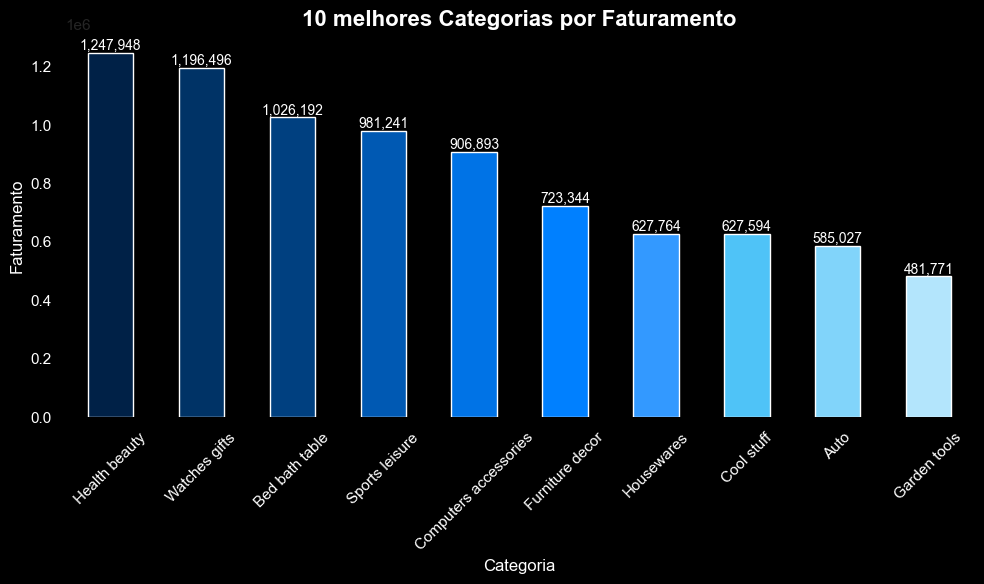

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#10 maiores categorias em faturamento:
top_10_faturamento = df_analise.groupby('Categoria')['Faturamento'].sum().sort_values(ascending=False).head(10)

#Ajustando a aparência:
plt.style.use("dark_background")
sns.set_theme(style="dark", palette="flare")
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

#Criando o gráfico:
plt.figure(figsize=(10,6), facecolor='black')

#Cores da barras:
cores_faturamento = ['#002147', '#003366', '#004080', '#0059b3', '#0073e6', 
                '#0080ff', '#3399ff', '#4fc3f7', '#81d4fa', '#b3e5fc']

#Gráfico:
top_10_faturamento.plot(kind='bar', color=cores_faturamento)

#Fundo do gráfico:
plt.gca().set_facecolor('black')

#Título:
plt.title('10 melhores Categorias por Faturamento',
          color='white', fontsize=16, fontweight='bold')

#Nomes dos eixos:
plt.xlabel('Categoria', color='white', fontsize=12)
plt.ylabel('Faturamento', color='white', fontsize=12)

#Fonte do texo (eixos):
plt.xticks(rotation=45, color='white', fontsize=11)
plt.yticks(color='white', fontsize=11)

#Grade discreta:
plt.grid(False)

#Valores nas barras:
for i, v in enumerate(top_10_faturamento):
    plt.text(i, v, f'{v:,.0f}',
             ha='center', va='bottom',
             color='white', fontsize=10)

#Remoção das bordas das barras:
for spine in plt.gca().spines.values():
    spine.set_visible(False)


plt.tight_layout()
plt.show()

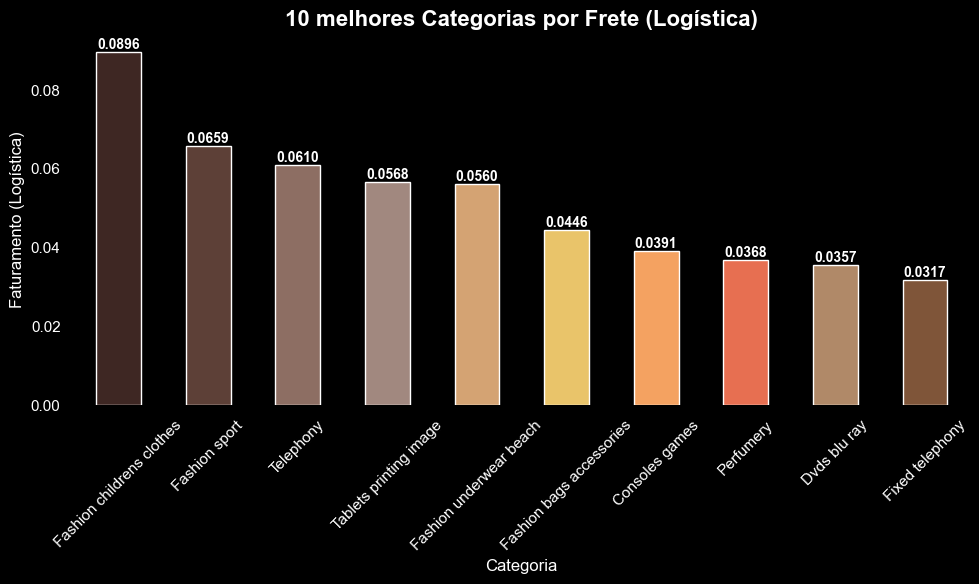

In [8]:
#Dados de frete (usando a média por categoria)
top_10_frete = df_analise.groupby('Categoria')['Frete por grama'].mean().sort_values(ascending=False).head(10)

#Ajustando a aparência:
plt.style.use("dark_background")
plt.figure(figsize=(10, 6), facecolor='black')

#Cores das barras:
cores_frete = ['#3e2723', '#5d4037', '#8d6e63', '#a1887f', '#d4a373', 
              '#e9c46a', '#f4a261', '#e76f51', '#b08968', '#7f5539']

#Gráfico:
top_10_frete.plot(kind='bar', color=cores_frete)

#Fundo do gráfico:
plt.gca().set_facecolor('black')

#Título:
plt.title('10 melhores Categorias por Frete (Logística)', 
          color='white', fontsize=16, fontweight='bold')

#Nomes dos eixos:
plt.xlabel('Categoria', color='white', fontsize=12)
plt.ylabel('Faturamento (Logística)', color='white', fontsize=12)

#Fonte do texto (eixos):
plt.xticks(rotation=45, color='white', fontsize=11)
plt.yticks(color='white', fontsize=11)

#Remoção da grade:
plt.grid(False)

#Valores nas barras (apenas 4 casas decimais):
for i, v in enumerate(top_10_frete):
    plt.text(i, v, f'{v:.4f}', 
             ha='center', va='bottom', 
             color='white', fontsize=10, fontweight='bold')

#Remoção das bordas das barras:
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


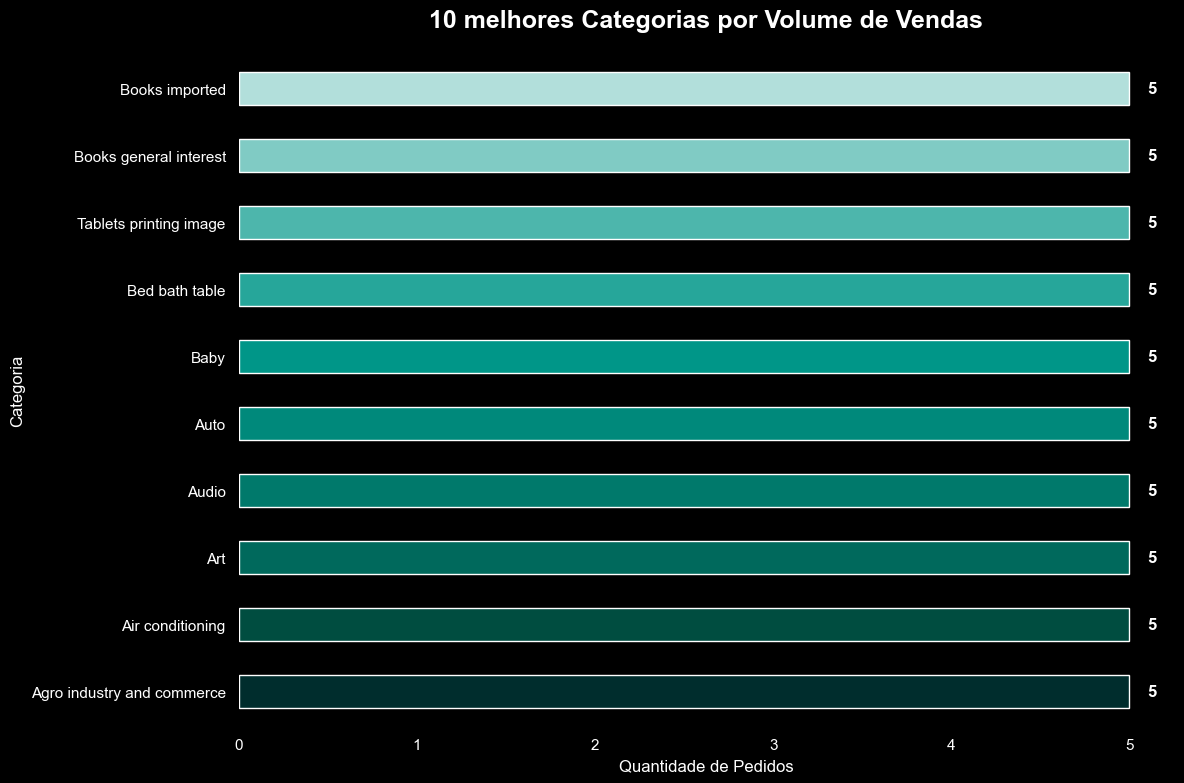

In [9]:
#Dados de volume (contagem de pedidos por categoria):
top_10_volume = df_analise.groupby('Categoria')['Faturamento'].count().sort_values(ascending=False).head(10)

#Ajustando a aparência:
plt.style.use("dark_background")
plt.figure(figsize=(12, 8), facecolor='black')

#Cores das barras:
cores_volume = ['#002d2d', '#004d40', '#00695c', '#00796b', '#00897b', 
                   '#009688', '#26a69a', '#4db6ac', '#80cbc4', '#b2dfdb']

#Gráfico (horizontal):
top_10_volume.plot(kind='barh', color=cores_volume)

#Fundo do gráfico:
plt.gca().set_facecolor('black')

#Título:
plt.title('10 melhores Categorias por Volume de Vendas', 
          color='white', fontsize=18, fontweight='bold', pad=20)

#Nomes dos eixos:
plt.xlabel('Quantidade de Pedidos', color='white', fontsize=12)
plt.ylabel('Categoria', color='white', fontsize=12)

#Fonte do texto (eixos):
plt.xticks(color='white', fontsize=11)
plt.yticks(color='white', fontsize=11)

#Remoção da grade:
plt.grid(False)

#Valores no topo das barras
for i, v in enumerate(top_10_volume):
    # v + 0.1 serve para dar um pequeno espaço entre a barra e o número
    plt.text(v + 0.1, i, f'{v}', color='white', fontweight='bold', va='center')

#Remoção das bordas das barras:
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\Amanda\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:96: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\Amanda\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


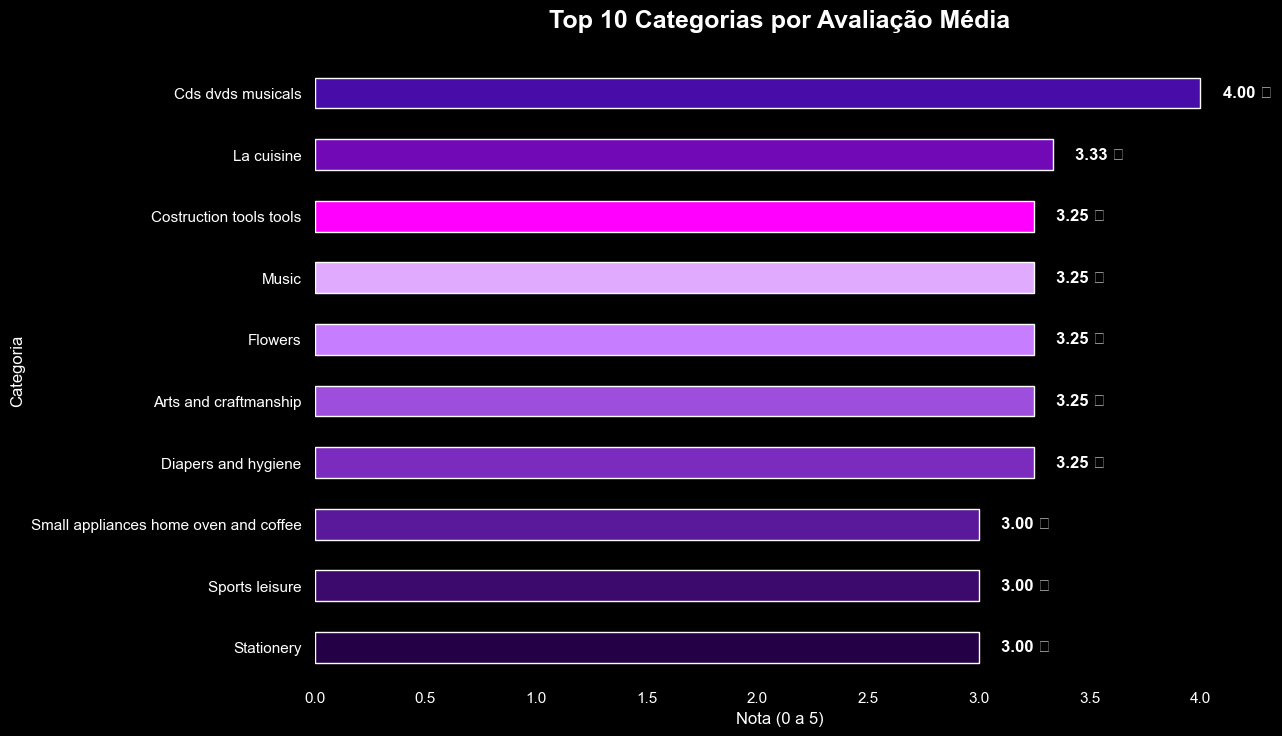

In [10]:
#Avaliação (satisfação):
top_10_notas = df_analise.groupby('Categoria')['Avaliacao'].mean().sort_values(ascending=True).tail(10)

#Ajustando a aparência:
plt.style.use("dark_background")
plt.figure(figsize=(12, 8), facecolor='black')

#Cores das barras:

cores_avaliacao = ['#240046', '#3c096c', '#5a189a', '#7b2cbf', '#9d4edd', 
               '#c77dff', '#e0aaff', '#ff00ff', '#7209b7', '#480ca8']

#Gráfico (horizontal):
top_10_notas.plot(kind='barh', color=cores_avaliacao)

#Fundo do gráfico:
plt.gca().set_facecolor('black')

#Título:
plt.title('Top 10 Categorias por Avaliação Média', 
          color='white', fontsize=18, fontweight='bold', pad=25)

#Nomes dos eixos:
plt.xlabel('Nota (0 a 5)', color='white', fontsize=12)
plt.ylabel('Categoria', color='white', fontsize=12)

#Fonte do texto (eixos):
plt.xticks(color='white', fontsize=11)
plt.yticks(color='white', fontsize=11)

#Remoção da grade:
plt.grid(False)

#Remoção das bordas das barras:
for spine in plt.gca().spines.values():
    spine.set_visible(False)

#Valores na frente das barras:
for i, v in enumerate(top_10_notas):
    # f'{v:.2f}' garante duas casas decimais para a nota
    plt.text(v + 0.1, i, f'{v:.2f} ★', color='white', fontweight='bold', va='center')

In [11]:
# Conclusão: 

#Após a análise dos dados de e-commerce, as seguintes conclusões foram obtidas:

#1. Eficiência Logística: A análise de correlação obteve um valor de **0,90**, indicando uma relação quase linear entre o peso do produto e o valor do frete. Isso sugere que a otimização de embalagens é a maneira mais eficiente para diminuir os custos logísticos.
#2. Volume x Faturamento: Determinamos as 10 categorias com maior rotatividade. Produtos de entrada para atrair clientes para o ecossistema podem ser categorias com alto volume e baixa margem.
#3. Satisfação do Cliente (NPS):** O ranking das avaliações médias (Notas) evidencia as categorias com a melhor percepção de qualidade. É preciso priorizar a revisão de fornecedores ou processos de entrega nas categorias que apresentam um alto faturamento, mas baixas notas.
#4. Visão Geral: O painel visual (Dark Premium) possibilita uma análise rápida do desempenho por categoria, simplificando a tomada de decisões para campanhas de marketing e logística futuras.